In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/online_retail.csv', encoding='ISO-8859-1')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  str           
 1   StockCode    397884 non-null  str           
 2   Description  397884 non-null  str           
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.3 MB


In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


In [12]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',   # Frequency
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'InvoiceDate': 'max'
}).reset_index()

customer_df.head()

,CustomerID,InvoiceNo,Quantity,TotalPrice,InvoiceDate
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00
3,12349.0,1,631,1757.55,2011-11-21 09:51:00
4,12350.0,1,197,334.40,2011-02-02 16:01:00


In [ ]:
customer_df.columns = ['CustomerID', 'Frequency', 'TotalQuantity', 'Monetary', 'LastPurchase']

In [ ]:
import datetime as dt
#Recency (RFM Analysis) or Feature Engineering
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

customer_df['Recency'] = (snapshot_date - customer_df['LastPurchase']).dt.days

customer_df.head()

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,326
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00,2
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00,75
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,19
4,12350.0,1,197,334.40,2011-02-02 16:01:00,310


In [ ]:
rfm = customer_df[['Recency', 'Frequency', 'Monetary']] #RFM dataset
rfm.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
#Machine Learning (Clustering)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

customer_df.head()

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency,Cluster
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,326,3
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00,2,0
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00,75,0
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,19,0
4,12350.0,1,197,334.40,2011-02-02 16:01:00,310,1


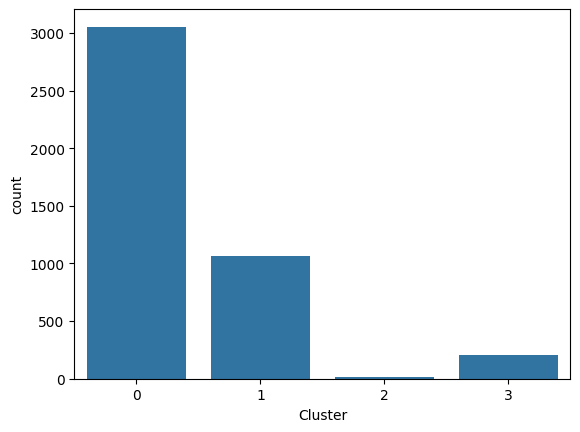

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
#Visualization (Clusters)
sns.countplot(x='Cluster', data=customer_df)
plt.show()

In [20]:
#Cluster Behavior
customer_df.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()


,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


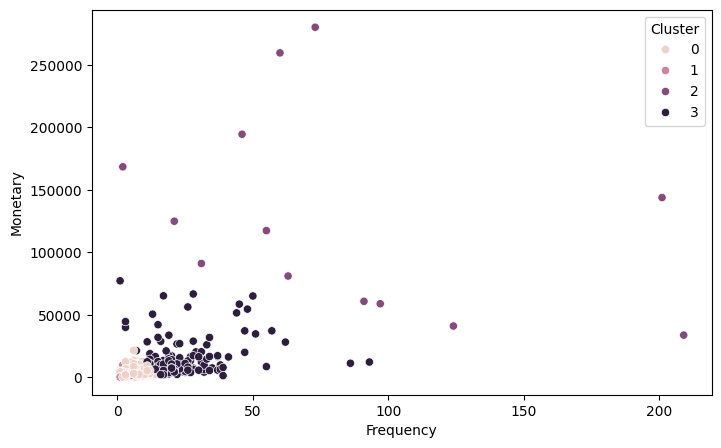

In [ ]:
#Cluster Visualization (Better Insight)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='Cluster')
plt.show()
#Cluster 0 → High Value Customers
#high spending
#frequent buyers

#Cluster 1 → Regular Customers
#medium spending

#Cluster 2 → New / Low activity
#low frequency

#Cluster 3 → Lost Customers
#high recency (long time no purchase)


In [22]:
#SIMPLE RECOMMENDATION SYSTEM
#Create product-customer matrix
customer_product = df.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [23]:
#Similarity Model
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(customer_product)

In [24]:
#Function (recommendation)
import numpy as np

def get_similar_customers(customer_id):
    idx = list(customer_product.index).index(customer_id)
    scores = list(enumerate(similarity[idx]))
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]
    
    similar_customers = [customer_product.index[i[0]] for i in sorted_scores]
    return similar_customers

# Example
get_similar_customers(customer_product.index[0])

[np.float64(15567.0),
 np.float64(18242.0),
 np.float64(17030.0),
 np.float64(17309.0),
 np.float64(16750.0)]

In [25]:
#Dataset check (Sanity Check)
customer_df.shape

(4338, 7)

In [26]:
#How many products
df['StockCode'].nunique()

3665

In [27]:
#How many transaction
df['InvoiceNo'].nunique()

18532

In [ ]:
#Cluster analysis
#Cluster Size
customer_df['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [29]:
#Cluster Behavior
customer_df.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [ ]:
#Check high value customers
customer_df.sort_values('Monetary', ascending=False).head(10)

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency,Cluster
1689,14646.0,73,196915,280206.02,2011-12-08 12:12:00,2,2
4201,18102.0,60,64124,259657.30,2011-12-09 11:50:00,1,2
3728,17450.0,46,69993,194550.79,2011-12-01 13:29:00,8,2
3008,16446.0,2,80997,168472.50,2011-12-09 09:15:00,1,2
1879,14911.0,201,80265,143825.06,2011-12-08 15:54:00,1,2
55,12415.0,21,77374,124914.53,2011-11-15 14:22:00,24,2
1333,14156.0,55,57885,117379.63,2011-11-30 10:54:00,10,2
3771,17511.0,31,64549,91062.38,2011-12-07 10:12:00,3,2
2702,16029.0,63,40208,81024.84,2011-11-01 10:27:00,39,2
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,326,3


In [31]:
#Most active customers:
customer_df.sort_values('Frequency', ascending=False).head(10)

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency,Cluster
326,12748.0,209,25747,33719.73,2011-12-09 12:20:00,1,2
1879,14911.0,201,80265,143825.06,2011-12-08 15:54:00,1,2
4010,17841.0,124,23071,40991.57,2011-12-08 12:07:00,2,2
562,13089.0,97,31070,58825.83,2011-12-07 09:02:00,3,2
1661,14606.0,93,6224,12156.65,2011-12-08 19:28:00,1,3
2176,15311.0,91,38194,60767.90,2011-12-09 12:00:00,1,2
481,12971.0,86,9289,11189.91,2011-12-06 12:20:00,4,3
1689,14646.0,73,196915,280206.02,2011-12-08 12:12:00,2,2
2702,16029.0,63,40208,81024.84,2011-11-01 10:27:00,39,2
795,13408.0,62,16232,28117.04,2011-12-08 09:05:00,2,3


In [32]:
#Lost customers:
customer_df.sort_values('Recency', ascending=False).head(10)

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency,Cluster
4180,18074.0,1,190,489.60,2010-12-01 09:53:00,374,1
4064,17908.0,1,173,243.28,2010-12-01 11:45:00,374,1
355,12791.0,1,97,192.60,2010-12-01 11:27:00,374,1
3103,16583.0,1,111,233.45,2010-12-01 12:03:00,374,1
1037,13747.0,1,8,79.60,2010-12-01 10:37:00,374,1
1749,14729.0,1,197,313.49,2010-12-01 12:43:00,374,1
4108,17968.0,1,160,277.35,2010-12-01 12:23:00,374,1
2206,15350.0,1,51,115.65,2010-12-01 13:33:00,373,1
2214,15363.0,1,144,326.00,2010-12-02 12:28:00,373,1
4138,18011.0,1,71,102.79,2010-12-01 17:35:00,373,1


In [33]:
#Recommendation system test
customer_product.index[0]

np.float64(12346.0)

In [34]:
get_similar_customers(customer_product.index[0])

[np.float64(15567.0),
 np.float64(18242.0),
 np.float64(17030.0),
 np.float64(17309.0),
 np.float64(16750.0)]

In [35]:
#Check pivot table
customer_product.shape

(4338, 3665)

In [36]:
#Check sparsity (real-world check)
(customer_product == 0).sum().sum() / customer_product.size

np.float64(0.9832193308035779)

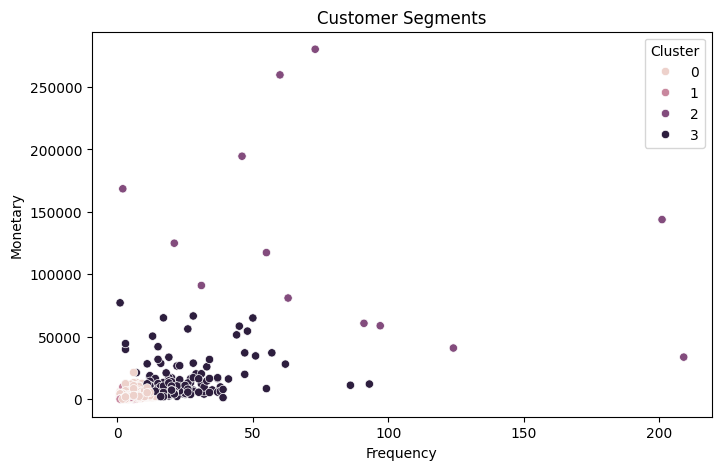

In [37]:
#Cluster Visualization (FINAL INSIGHT)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='Cluster')
plt.title("Customer Segments")
plt.show()

# Customer Analytics & Recommendation System

## Objective
Segment customers and build a recommendation system using retail transaction data.

## Steps
- Data Cleaning
- RFM Analysis
- KMeans Clustering
- Customer Segmentation
- Recommendation System (Cosine Similarity)

## Results
- Identified high-value and low-value customers
- Grouped customers into behavioral clusters
- Built basic recommendation system for customer similarity

## Tools Used
Python, Pandas, Scikit-learn, Matplotlib, Seaborn